# Job Market Skills Analysis

## Objective
This project analyzes data analyst job postings to identify:
- the most in-demand skills
- common skill combinations
- geographic job trends

## Dataset
The dataset contains over 2,000 job postings with information on job titles, salaries, descriptions, and locations.

In [33]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [34]:
# Upload dataset
from google.colab import files
uploaded = files.upload()

Saving DataAnalyst.csv to DataAnalyst (1).csv


In [35]:
# Load dataset
df = pd.read_csv("DataAnalyst.csv")
df.head()

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,True
1,1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1
2,2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1
3,3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1
4,4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True


In [36]:
# Inspecting the data
df.info()
df.head()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2253 entries, 0 to 2252
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         2253 non-null   int64  
 1   Job Title          2253 non-null   object 
 2   Salary Estimate    2253 non-null   object 
 3   Job Description    2253 non-null   object 
 4   Rating             2253 non-null   float64
 5   Company Name       2252 non-null   object 
 6   Location           2253 non-null   object 
 7   Headquarters       2253 non-null   object 
 8   Size               2253 non-null   object 
 9   Founded            2253 non-null   int64  
 10  Type of ownership  2253 non-null   object 
 11  Industry           2253 non-null   object 
 12  Sector             2253 non-null   object 
 13  Revenue            2253 non-null   object 
 14  Competitors        2253 non-null   object 
 15  Easy Apply         2253 non-null   object 
dtypes: float64(1), int64(2),

Index(['Unnamed: 0', 'Job Title', 'Salary Estimate', 'Job Description',
       'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'Easy Apply'],
      dtype='object')

## Data Cleaning

In [37]:
# Inspecting the data for null values
df.isnull().sum()

,0
Unnamed: 0,0
Job Title,0
Salary Estimate,0
Job Description,0
Rating,0
Company Name,1
Location,0
Headquarters,0
Size,0
Founded,0


In [38]:
# Inspecting the data for duplicate values
df.duplicated().sum()

np.int64(0)

In [39]:
# Cleaning the data. Removing the null value present
df= df.dropna()
df.isnull().sum()


,0
Unnamed: 0,0
Job Title,0
Salary Estimate,0
Job Description,0
Rating,0
Company Name,0
Location,0
Headquarters,0
Size,0
Founded,0


In [40]:
# Dropping the unnamed column
df = df.drop(columns=["Unnamed: 0"])
df.head()

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,True
1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1
2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1
3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1
4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True


In [41]:
# Matching all text up to ensure that search is unified
df["Job Description"] = df["Job Description"].astype(str).str.lower()
df["Job Title"] = df["Job Title"].astype(str).str.strip()
df["Location"] = df["Location"].astype(str).str.strip()
df["Company Name"] = df["Company Name"].astype(str).str.strip()
df

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,True
1,Quality Data Analyst,$37K-$66K (Glassdoor est.),overview\n\nprovides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1
2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),we’re looking for a senior data analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1
3,Data Analyst,$37K-$66K (Glassdoor est.),requisition numberrr-0001939\nremote:yes\nwe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1
4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),about fanduel group\n\nfanduel group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2248,RQS - IHHA - 201900004460 -1q Data Security An...,$78K-$104K (Glassdoor est.),maintains systems to protect data from unautho...,2.5,"Avacend, Inc.\n2.5","Denver, CO","Alpharetta, GA",51 to 200 employees,-1,Company - Private,Staffing & Outsourcing,Business Services,Unknown / Non-Applicable,-1,-1
2249,Senior Data Analyst (Corporate Audit),$78K-$104K (Glassdoor est.),position:\nsenior data analyst (corporate audi...,2.9,Arrow Electronics\n2.9,"Centennial, CO","Centennial, CO",10000+ employees,1935,Company - Public,Wholesale,Business Services,$10+ billion (USD),"Avnet, Ingram Micro, Tech Data",-1
2250,"Technical Business Analyst (SQL, Data analytic...",$78K-$104K (Glassdoor est.),"title: technical business analyst (sql, data a...",-1.0,Spiceorb,"Denver, CO",-1,-1,-1,-1,-1,-1,-1,-1,-1
2251,"Data Analyst 3, Customer Experience",$78K-$104K (Glassdoor est.),summary\n\nresponsible for working cross-funct...,3.1,Contingent Network Services\n3.1,"Centennial, CO","West Chester, OH",201 to 500 employees,1984,Company - Private,Enterprise Software & Network Solutions,Information Technology,$25 to $50 million (USD),-1,-1


## Location Analysis

In [42]:
# Counting how many job postings per location
top_locations = df["Location"].value_counts().head(10)
top_locations

,count
Location,
"New York, NY",310
"Chicago, IL",130
"San Francisco, CA",119
"Austin, TX",81
"Los Angeles, CA",80
"Charlotte, NC",78
"Houston, TX",72
"Dallas, TX",66
"San Diego, CA",62


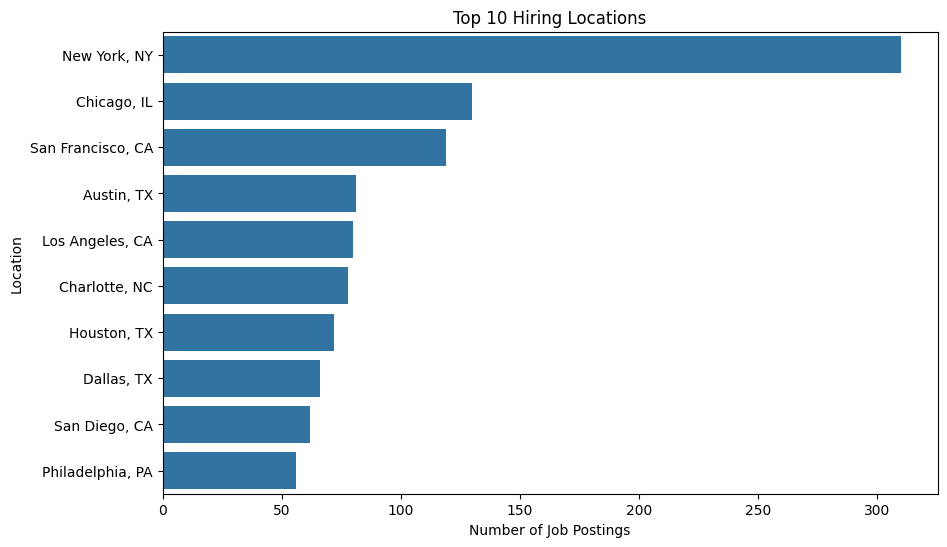

In [43]:
# Visualizing job location postings
plt.figure(figsize=(10,6))
sns.barplot(x=top_locations.values, y=top_locations.index)
plt.title("Top 10 Hiring Locations")
plt.xlabel("Number of Job Postings")
plt.ylabel("Location")
plt.show()

## Insight: Hiring Locations

Data analyst job postings are heavily concentrated in major metropolitan areas, with New York significantly leading all other locations. Cities like Chicago and San Francisco also show strong demand, while mid-sized cities such as Austin, Charlotte, and Dallas demonstrate steady but lower levels of job availability.

This suggests that data analyst opportunities are primarily centered in large business and technology hubs, where companies have greater demand for data-driven decision making.

## Skill Analysis

In [44]:
# Skill extraction. Creating a skills list.
skills = [
    "python", "sql", "excel", "tableau", "power bi", "r",
    "sas", "aws", "azure", "pandas", "numpy",
    "matplotlib", "seaborn", "scikit-learn", "spark", "looker"
]

In [45]:
# Count for data analyst skills
skill_counts = {}
for skill in skills:
    count = df["Job Description"].str.contains(rf"\b{re.escape(skill)}\b", regex=True, na=False).sum()
    skill_counts[skill] = count
skills_df = pd.DataFrame(skill_counts.items(), columns=["Skill", "Count"])
skills_df = skills_df.sort_values(by="Count", ascending=False)

skills_df

,Skill,Count
1,sql,1362
2,excel,903
0,python,633
3,tableau,617
5,r,441
6,sas,338
4,power bi,180
7,aws,132
15,looker,107
14,spark,71


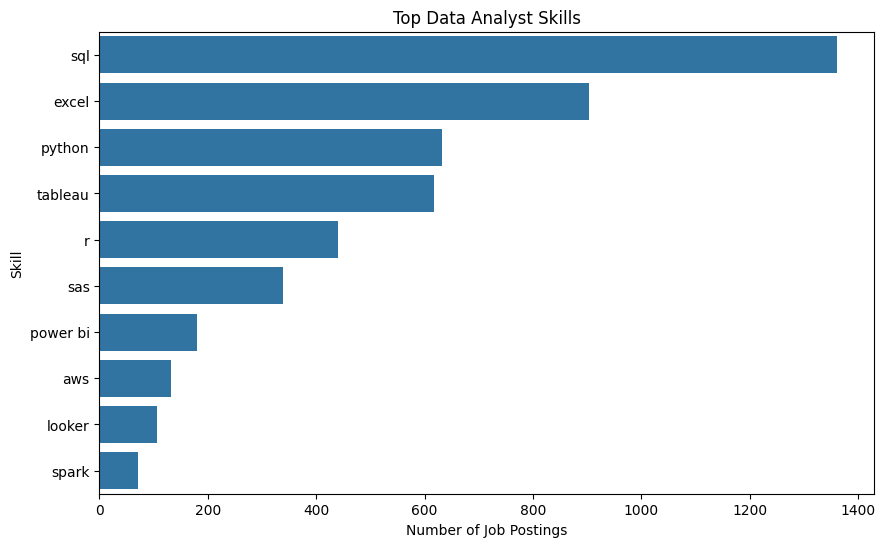

In [46]:
# Visualizing the top skills
top_skills = skills_df.head(10)
plt.figure(figsize=(10,6))
sns.barplot(data=top_skills, x="Count", y="Skill")
plt.title("Top Data Analyst Skills")
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")
plt.show()

## Insight: Top Skills

SQL is the most in-demand skill, appearing significantly more frequently than any other tool. Excel and Python also rank highly, indicating that employers expect a mix of database querying, spreadsheet analysis, and programming skills.

## Skill Combinations

In [47]:
# Skill combinations
df["python_skill"] = df["Job Description"].str.contains(r"\bpython\b", regex=True, na=False)
df["sql_skill"] = df["Job Description"].str.contains(r"\bsql\b", regex=True, na=False)
df["excel_skill"] = df["Job Description"].str.contains(r"\bexcel\b", regex=True, na=False)
df["tableau_skill"] = df["Job Description"].str.contains(r"\btableau\b", regex=True, na=False)
df["powerbi_skill"] = df["Job Description"].str.contains(r"\bpower bi\b", regex=True, na=False)

In [48]:
# Counting commmon pairs
python_sql = ((df["python_skill"]) & (df["sql_skill"])).sum()
sql_excel = ((df["sql_skill"]) & (df["excel_skill"])).sum()
sql_tableau = ((df["sql_skill"]) & (df["tableau_skill"])).sum()
sql_powerbi = ((df["sql_skill"]) & (df["powerbi_skill"])).sum()

In [49]:
# Table for common pairs
pair_df = pd.DataFrame({
    "Skill Pair": ["Python + SQL", "SQL + Excel", "SQL + Tableau", "SQL + Power BI"],
    "Count": [python_sql, sql_excel, sql_tableau, sql_powerbi]
})

pair_df

,Skill Pair,Count
0,Python + SQL,547
1,SQL + Excel,610
2,SQL + Tableau,515
3,SQL + Power BI,142


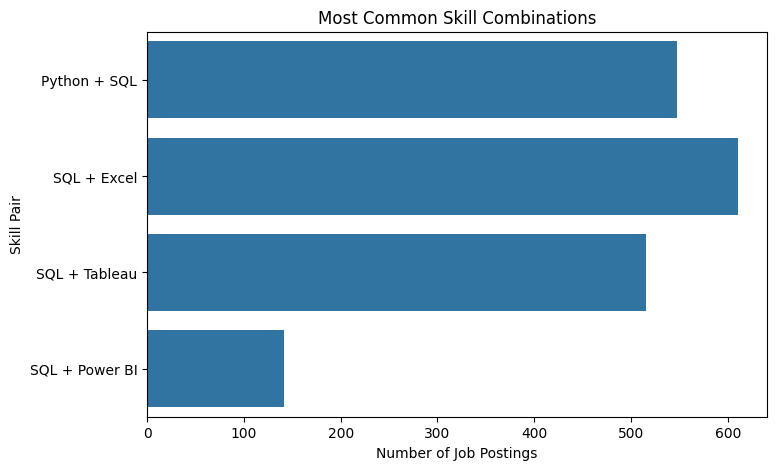

In [50]:
# Creating a common pairs visualization
plt.figure(figsize=(8,5))
sns.barplot(data=pair_df, x="Count", y="Skill Pair")
plt.title("Most Common Skill Combinations")
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill Pair")
plt.show()

## Insight: Skill Combinations

SQL appears in all of the most common skill combinations, reinforcing its role as a foundational requirement for data analyst positions. The most frequent pairing, SQL and Excel, highlights the continued importance of spreadsheet-based analysis alongside database querying.

Combinations such as Python and SQL are also highly represented, indicating that programming skills are increasingly valuable. Visualization tools like Tableau appear more frequently than Power BI in this dataset, suggesting stronger demand for Tableau in these job postings.

## Salary Analysis

In [51]:
# Keep only rows with a real salary estimate
salary_df = df[df["Salary Estimate"] != "-1"].copy()

In [52]:
# Remove text and symbols
salary_df["Salary Clean"] = salary_df["Salary Estimate"].str.replace(r"\(Glassdoor est\.\)", "", regex=True)
salary_df["Salary Clean"] = salary_df["Salary Clean"].str.replace(r"\(Employer est\.\)", "", regex=True)
salary_df["Salary Clean"] = salary_df["Salary Clean"].str.replace("$", "", regex=False)
salary_df["Salary Clean"] = salary_df["Salary Clean"].str.replace("K", "", regex=False)
salary_df["Salary Clean"] = salary_df["Salary Clean"].str.strip()

In [53]:
# Split into min and max salary
salary_split = salary_df["Salary Clean"].str.split("-", expand=True)
salary_df["Min Salary"] = pd.to_numeric(salary_split[0], errors="coerce")
salary_df["Max Salary"] = pd.to_numeric(salary_split[1], errors="coerce")

In [54]:
# Create average salary
salary_df["Avg Salary"] = (salary_df["Min Salary"] + salary_df["Max Salary"]) / 2

In [55]:
# Check results
salary_df[["Salary Estimate", "Min Salary", "Max Salary", "Avg Salary"]].head()

,Salary Estimate,Min Salary,Max Salary,Avg Salary
0,$37K-$66K (Glassdoor est.),37,66,51.5
1,$37K-$66K (Glassdoor est.),37,66,51.5
2,$37K-$66K (Glassdoor est.),37,66,51.5
3,$37K-$66K (Glassdoor est.),37,66,51.5
4,$37K-$66K (Glassdoor est.),37,66,51.5


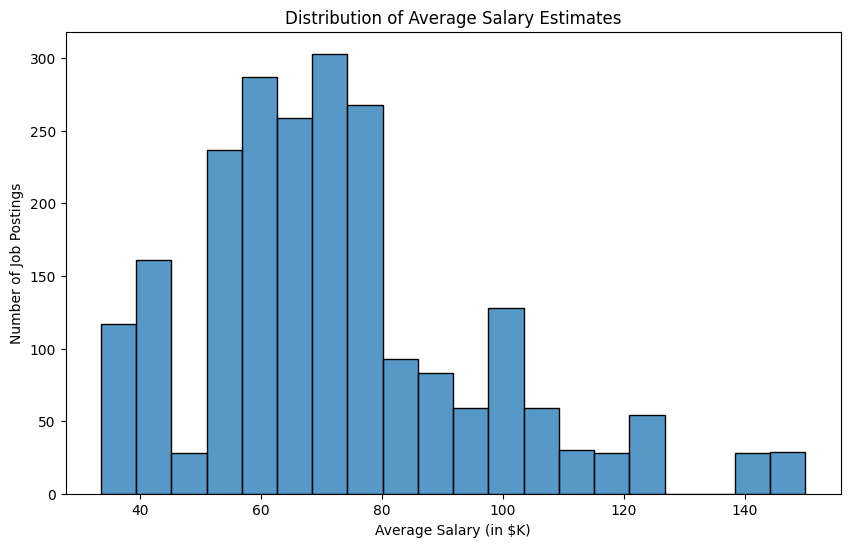

In [56]:
# Create a salary visualization
plt.figure(figsize=(10,6))
sns.histplot(salary_df["Avg Salary"].dropna(), bins=20)
plt.title("Distribution of Average Salary Estimates")
plt.xlabel("Average Salary (in $K)")
plt.ylabel("Number of Job Postings")
plt.show()

## Insight: Salary Distribution

The salary distribution is concentrated between approximately \$50K and \$80K, indicating that most data analyst roles fall within a mid-range compensation band. The relatively smaller number of postings at higher salary levels suggests fewer senior-level or specialized roles in the dataset. Overall, this distribution reflects a job market primarily composed of entry to mid-level data analyst positions.

## Final Insights

This analysis shows that SQL is the most essential skill for data analyst roles, appearing more frequently than any other technical tool in job postings. Excel also remains highly relevant, highlighting the continued importance of spreadsheet-based analysis in business environments. Python is strongly valued as well, but it appears less consistently than SQL and Excel, suggesting that it is often preferred rather than universally required.

The data also shows that employers frequently look for combinations of skills rather than a single technical ability. SQL is commonly paired with Excel, Python, and Tableau, indicating that data analysts are expected to blend querying, analysis, and visualization skills in the workplace.

From a geographic perspective, job opportunities are concentrated in major metropolitan areas such as New York, Chicago, and San Francisco, where demand for data-driven decision making is strongest. Salary estimates are mostly concentrated within a mid-range band, suggesting that many data analyst roles offer relatively similar compensation levels across postings.

Overall, the job market for data analysts favors candidates with a well-rounded technical skill set and the ability to work across multiple tools in business and technology-focused environments.